# Notebook 6 — Bubble-Driven US NFA Dynamics

This notebook simulates a **specific sample-path realization** of the two-country OLG model:

- **t = 1, ..., 39**: Economy in unbalanced state $u$ (higher US growth, bubble building)
- **t = 40**: Regime switches to balanced growth $b$ — **the bubble bursts**
- **t = 40, ..., 120**: Economy in balanced state $b$ (common growth rate)

### Goals
1. **Stock price decomposition**: $Q_{US,t} = V_t + B_t$ (fundamental + bubble)
2. **NFA dynamics**: How the bubble drives US Net Foreign Assets
3. **NFA decomposition**: $\text{NFA} = A - Q_{US} = (A - V) + (-B)$ separates fundamental and bubble contributions

In [1]:
using Pkg; Pkg.activate(".")
include("TwoCountryOLG.jl")
using Plots, LaTeXStrings, Printf
gr()

# ── Scenario parameters ──
const tau = 40    # switch date (bubble bursts at t = tau)

  Activating project at `~/Documents/GitHub/Open_HKT`


40

In [2]:
# ── Run the full simulation ──
result = run_simulation(ModelParams(); verbose=true)

p      = result.params
paths  = result.paths
u_path = result.u_path
bs     = result.balanced_states
T      = p.T_max

@printf("T_max = %d,  switch date tau = %d\n", T, tau)

Generating exogenous paths...
Solving balanced-growth states...
  t= 20: ω_b=0.6759  θ_b=-0.867039  R_f_b=1.0633
  t= 40: ω_b=0.7859  θ_b=-0.646340  R_f_b=1.0527
  t= 60: ω_b=0.7989  θ_b=-0.620524  R_f_b=1.0513
  t= 80: ω_b=0.7999  θ_b=-0.618247  R_f_b=1.0510
  t=100: ω_b=0.8000  θ_b=-0.618052  R_f_b=1.0510
  t=120: ω_b=0.8000  θ_b=-0.618036  R_f_b=1.0510
Solving u-path by backward induction...
  t=110: ω=0.9412  θ=-0.618039  θ*_US=+368035.2567  R_f=1.1877  q_US=0.470597  ‖F‖=3.2e-09
  t=100: ω=0.9263  θ=-0.618052  θ*_US=+108380.1609  R_f=1.1877  q_US=0.463151  ‖F‖=8.3e-09
  t= 90: ω=0.9079  θ=-0.618097  θ*_US=+31917.7530  R_f=1.1877  q_US=0.453991  ‖F‖=4.7e-10
  t= 80: ω=0.8857  θ=-0.618249  θ*_US=+9401.3568  R_f=1.1877  q_US=0.442925  ‖F‖=6.7e-11
  t= 70: ω=0.8592  θ=-0.618769  θ*_US=+2770.8095  R_f=1.1878  q_US=0.429775  ‖F‖=1.0e-12
  t= 60: ω=0.8281  θ=-0.620534  θ*_US=+818.2669  R_f=1.1878  q_US=0.414497  ‖F‖=6.3e-14
  t= 50: ω=0.7928  θ=-0.626464  θ*_US=+243.2631  R_f=1.1880  q_U

## 1. Constructing the Realized Sample Path

After the switch at $\tau = 40$, all exogenous variables grow at the balanced rate $g_b$ (not $g_{e,u}$). We construct the realized path by splicing u-path values (pre-switch) with balanced-state values (post-switch).

In [3]:
# ── Build realized exogenous paths ──
# Pre-switch: use u-path growth rates;  Post-switch: grow at g_b
e_US_real = zeros(T)
D_US_real = zeros(T)
e_W_real  = zeros(T)
D_W_real  = zeros(T)

for t in 1:T
    if t <= tau
        e_US_real[t] = paths.e_US[t]
        D_US_real[t] = paths.D_US[t]
        e_W_real[t]  = paths.e_W[t]
        D_W_real[t]  = paths.D_W[t]
    else
        # After switch: everything grows at g_b
        e_US_real[t] = e_US_real[t-1] * p.g_e_b
        D_US_real[t] = D_US_real[t-1] * p.g_e_b   # D and e grow at same rate in balanced state
        e_W_real[t]  = e_W_real[t-1]  * p.g_e_b
        D_W_real[t]  = D_W_real[t-1]  * p.g_e_b
    end
end

@printf("e_US at switch (t=%d): %.4e\n", tau, e_US_real[tau])
@printf("e_US at t=%d (post):   %.4e  (growth = g_b = %.4f)\n",
        tau+5, e_US_real[tau+5], p.g_e_b)

e_US at switch (t=40): 8.1916e+02
e_US at t=45 (post):   1.0505e+03  (growth = g_b = 1.0510)


In [4]:
# ── Build realized equilibrium variables ──
omega_real      = zeros(T)
omega_star_real = zeros(T)
theta_real      = zeros(T)
theta_Us_real   = zeros(T)
Q_US_real       = zeros(T)
Q_W_real        = zeros(T)
R_f_real        = zeros(T)
A_real          = zeros(T)
A_star_real     = zeros(T)
NFA_real        = zeros(T)

bs_tau = bs[tau]   # balanced-state at the switch date

for t in 1:T
    A_real[t]      = p.β * e_US_real[t]
    A_star_real[t] = (p.β + p.χ) / (1 + p.χ) * e_W_real[t]

    if t < tau
        # Pre-switch: u-path equilibrium
        s = u_path[t]
        omega_real[t]      = s.ω
        omega_star_real[t] = s.ω_star
        theta_real[t]      = s.θ
        theta_Us_real[t]   = s.θ_US_star
        Q_US_real[t]       = s.Q_US
        Q_W_real[t]        = s.Q_W
        R_f_real[t]        = s.R_f
    else
        # Post-switch: balanced-state (detrended values × e_US_real)
        omega_real[t]      = bs_tau.ω_b
        omega_star_real[t] = bs_tau.ω_star_b
        theta_real[t]      = bs_tau.θ_b
        theta_Us_real[t]   = bs_tau.θ_US_star_b
        Q_US_real[t]       = bs_tau.Q_US_hat * e_US_real[t]
        Q_W_real[t]        = bs_tau.Q_W_hat  * e_US_real[t]
        R_f_real[t]        = bs_tau.R_f_b
    end

    # ── Total NFA (equity + bonds) ──
    # NFA_US = (1-ω)(1-θ)A - ω*(1-θ*_US)A* + θA  =  A - Q_US
    NFA_real[t] = A_real[t] - Q_US_real[t]
end

# ── Verify NFA identity: component formula vs A - Q_US ──
max_err = 0.0
for t in 1:T
    nfa_components = (1 - omega_real[t]) * (1 - theta_real[t]) * A_real[t] -
                     omega_star_real[t] * (1 - theta_Us_real[t]) * A_star_real[t] +
                     theta_real[t] * A_real[t]
    global max_err = max(max_err, abs(nfa_components - NFA_real[t]))
end
@printf("NFA identity check: max |(1-ω)(1-θ)A - ω*(1-θ*)A* + θA  −  (A−Q)| = %.2e\n", max_err)

@printf("\nPre-switch  (t=1):  ω=%.4f  θ=%.4f  NFA=%.4e  NFA/GDP=%.4f\n",
        omega_real[1], theta_real[1], NFA_real[1], NFA_real[1]/e_US_real[1])
@printf("At switch   (t=%d): ω=%.4f  θ=%.4f  NFA=%.4e  NFA/GDP=%.4f\n",
        tau, omega_real[tau], theta_real[tau], NFA_real[tau], NFA_real[tau]/e_US_real[tau])
@printf("Post-switch (t=%d): ω=%.4f  θ=%.4f  NFA=%.4e  NFA/GDP=%.4f\n",
        tau+1, omega_real[tau+1], theta_real[tau+1], NFA_real[tau+1], NFA_real[tau+1]/e_US_real[tau+1])

NFA identity check: max |(1-ω)(1-θ)A - ω*(1-θ*)A* + θA  −  (A−Q)| = 1.39e-10

Pre-switch  (t=1):  ω=0.4665  θ=-1.8345  NFA=-3.5846e-02  NFA/GDP=-0.0358
At switch   (t=40): ω=0.7859  θ=-0.6463  NFA=1.0493e+02  NFA/GDP=0.1281
Post-switch (t=41): ω=0.7859  θ=-0.6463  NFA=1.1028e+02  NFA/GDP=0.1281


## 2. Stock Price Decomposition: $Q_{US} = V + B$

We compute the **fundamental value** $V_t$ by backward recursion using the effective US pricing kernel, and define the **bubble component** as $B_t = Q_{US,t} - V_t$.

In [5]:
# ── Compute fundamental value by backward recursion (along full u-path) ──
Q_US_vec = [u_path[t].Q_US for t in 1:T]

V = zeros(T)
V[T] = bs[T].Q_US_hat * paths.e_US[T]   # terminal: balanced-state = fundamental

for t in (T-1):-1:1
    s = u_path[t]

    # Continuation values at t+1 under u and b
    V_u_next = V[t+1]
    D_u_next = paths.D_US[t+1]
    V_b_next = bs[t+1].Q_US_hat * paths.e_US[t+1]
    D_b_next = paths.D_US[t+1]

    # Next-period prices for kernel computation
    Q_US_next_u = u_path[t+1].Q_US
    Q_W_next_u  = u_path[t+1].Q_W
    Q_US_next_b = bs[t+1].Q_US_hat * paths.e_US[t+1]
    Q_W_next_b  = bs[t+1].Q_W_hat  * paths.e_US[t+1]

    ret_u = compute_returns(s.Q_US, s.Q_W,
                Q_US_next_u, Q_W_next_u,
                paths.D_US[t+1], paths.D_W[t+1],
                s.ω, s.ω_star, s.θ, s.θ_US_star, s.R_f)
    ret_b = compute_returns(s.Q_US, s.Q_W,
                Q_US_next_b, Q_W_next_b,
                paths.D_US[t+1], paths.D_W[t+1],
                s.ω, s.ω_star, s.θ, s.θ_US_star, s.R_f)

    # US kernel (normalised)
    M_u, M_b = us_kernel(ret_u.R_A, ret_b.R_A, p.γ, p.π_persist)

    # Wedge factor from home-bias cost
    phi = p.κ * s.C_y / ((1 - p.β) * s.S) * (s.ω - p.ω̄)
    denom_US = 1 + phi * (1 - s.ω)

    Meff_u = M_u / denom_US
    Meff_b = M_b / denom_US

    V[t] = p.π_persist * Meff_u * (V_u_next + D_u_next) +
           (1 - p.π_persist) * Meff_b * (V_b_next + D_b_next)
end

B = Q_US_vec .- V
bubble_share = B ./ Q_US_vec

@printf("At t=1:   Q_US = %.4e,  V = %.4e,  B = %.4e,  B/Q = %.4f\n",
        Q_US_vec[1], V[1], B[1], bubble_share[1])
@printf("At t=39:  Q_US = %.4e,  V = %.4e,  B = %.4e,  B/Q = %.4f\n",
        Q_US_vec[39], V[39], B[39], bubble_share[39])

At t=1:   Q_US = 5.3585e-01,  V = 4.6906e-01,  B = 6.6789e-02,  B/Q = 0.1246
At t=39:  Q_US = 2.6039e+02,  V = 2.6001e+02,  B = 3.8435e-01,  B/Q = 0.0015


In [6]:
# ── Construct realized V and B along the sample path ──
V_real = zeros(T)
B_real = zeros(T)

for t in 1:T
    if t < tau
        V_real[t] = V[t]
        B_real[t] = B[t]
    else
        # Post-switch: no bubble, Q = V (fundamental)
        V_real[t] = Q_US_real[t]
        B_real[t] = 0.0
    end
end

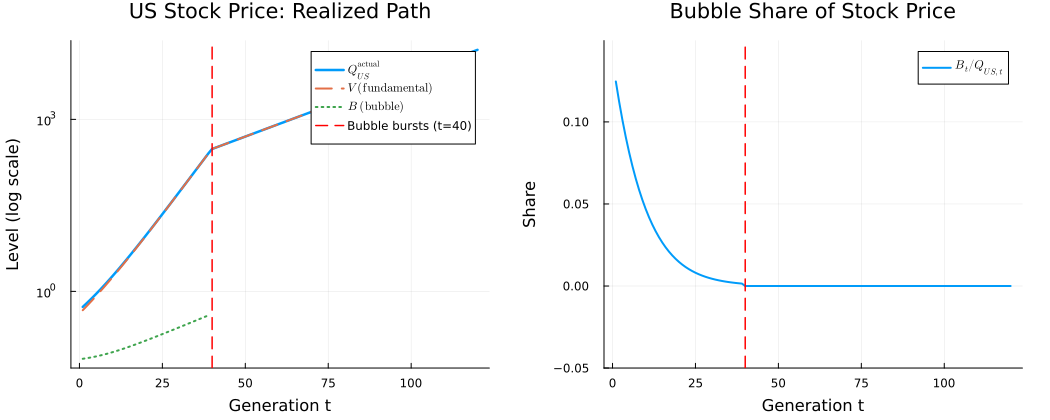

In [7]:
# ── Plot: Stock Price Decomposition ──
tt = 1:T

sp1 = plot(tt, Q_US_real, lw=2.5, label=L"Q_{US}^{\mathrm{actual}}",
           xlabel="Generation t", ylabel="Level (log scale)",
           title="US Stock Price: Realized Path", yscale=:log10)
plot!(sp1, tt, V_real, lw=2, ls=:dash, label=L"V\ (\mathrm{fundamental})")
plot!(sp1, tt[1:tau-1], B_real[1:tau-1], lw=2, ls=:dot, label=L"B\ (\mathrm{bubble})")
vline!(sp1, [tau], lc=:red, ls=:dash, lw=1.5, label="Bubble bursts (t=$tau)")

sp2 = plot(tt, B_real ./ Q_US_real, lw=2, label=L"B_t / Q_{US,t}",
           xlabel="Generation t", ylabel="Share",
           title="Bubble Share of Stock Price", ylims=(-0.05, maximum(bubble_share[1:tau-1])*1.2))
vline!(sp2, [tau], lc=:red, ls=:dash, lw=1.5, label="")

plot(sp1, sp2, layout=(1,2), size=(1050, 420), margin=5Plots.mm)

## 3. NFA Dynamics

US Total Net Foreign Assets include both equity and bond positions:

$$\text{NFA}_{US,t} = \underbrace{(1-\omega_t)S_t}_{\text{US holdings of RoW equity}} - \underbrace{\omega^*_t S^*_t}_{\text{RoW holdings of US equity}} + \underbrace{b_t}_{\text{US bond position}}$$

where $S_t = (1-\theta_t)A_t$ is US total equity investment, $S^*_t = (1-\theta^*_{US,t} - \theta^*_{W,t})A^*_t$ is RoW total equity investment, and $b_t = \theta_t A_t$ is the US bond position.

From the stock clearing identity $Q_{US} = \omega S + \omega^* S^*$, this simplifies to:

$$\text{NFA}_{US,t} = A_t - Q_{US,t}$$

Since $A = \beta \cdot e_{US}$ (US savings) is the same across regimes, the NFA gap between u-path and balanced-state is driven entirely by stock prices: $\Delta\text{NFA} = Q^b_{US} - Q^u_{US}$.

In [8]:
# ── Compute NFA paths ──
# Balanced-state counterfactual: NFA_b = A - Q_US^b at each date
NFA_b_counterfactual = zeros(T)
for t in 1:T
    A_b_t    = p.β * paths.e_US[t]
    Q_US_b_t = bs[t].Q_US_hat * paths.e_US[t]
    NFA_b_counterfactual[t] = A_b_t - Q_US_b_t
end

# Normalize by GDP (= e_US)
nfa_gdp_real = NFA_real ./ e_US_real
nfa_gdp_b    = NFA_b_counterfactual ./ paths.e_US[1:T]
nfa_gdp_gap  = nfa_gdp_real .- nfa_gdp_b[1:T]

@printf("NFA/GDP at t=1:   realized = %.4f,  balanced = %.4f,  gap = %.4f\n",
        nfa_gdp_real[1], nfa_gdp_b[1], nfa_gdp_gap[1])
@printf("NFA/GDP at t=39:  realized = %.4f,  balanced = %.4f,  gap = %.4f\n",
        nfa_gdp_real[39], nfa_gdp_b[39], nfa_gdp_gap[39])
@printf("NFA/GDP at t=40:  realized = %.4f,  balanced = %.4f,  gap = %.4f\n",
        nfa_gdp_real[40], nfa_gdp_b[40], nfa_gdp_gap[40])

NFA/GDP at t=1:   realized = -0.0358,  balanced = -0.0163,  gap = -0.0196
NFA/GDP at t=39:  realized = 0.1225,  balanced = 0.1300,  gap = -0.0075
NFA/GDP at t=40:  realized = 0.1281,  balanced = 0.1281,  gap = 0.0000


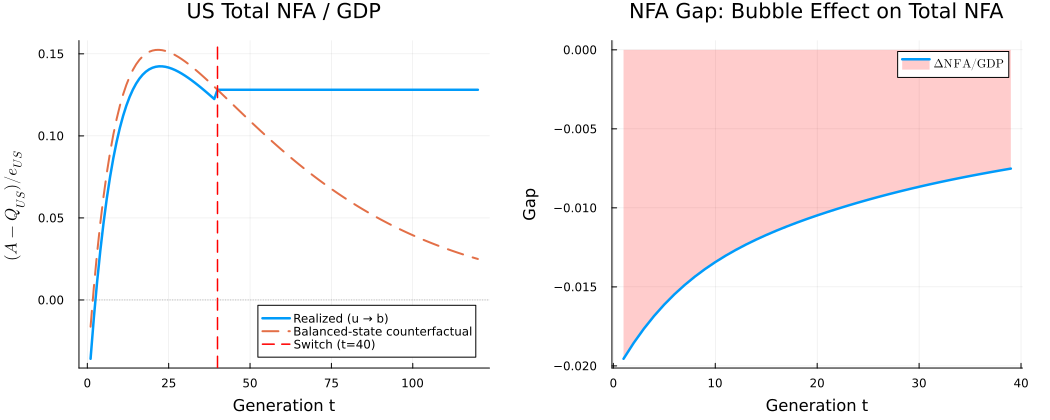

In [9]:
# ── Plot: NFA Dynamics ──
np1 = plot(tt, nfa_gdp_real, lw=2.5, label="Realized (u → b)",
           xlabel="Generation t", ylabel=L"(A - Q_{US}) / e_{US}",
           title="US Total NFA / GDP")
plot!(np1, tt, nfa_gdp_b, lw=2, ls=:dash, label="Balanced-state counterfactual")
vline!(np1, [tau], lc=:red, ls=:dash, lw=1.5, label="Switch (t=$tau)")
hline!(np1, [0], lc=:gray, ls=:dot, lw=0.5, label="")

np2 = plot(tt[1:tau-1], nfa_gdp_gap[1:tau-1], lw=2.5,
           label=L"\Delta\mathrm{NFA/GDP}",
           xlabel="Generation t", ylabel="Gap",
           title="NFA Gap: Bubble Effect on Total NFA",
           fill=0, fillalpha=0.2, fc=:red)

plot(np1, np2, layout=(1,2), size=(1050, 420), margin=5Plots.mm)

## 4. NFA Decomposition: $\text{NFA} = A - V - B$

Since $\text{NFA} = A - Q_{US}$ and $Q_{US} = V + B$ (fundamental + bubble):

$$\text{NFA}_{US,t} = \underbrace{(A_t - V_t)}_{\text{Fundamental NFA}} + \underbrace{(-B_t)}_{\text{Bubble effect on NFA}}$$

### Gap decomposition vs balanced state

The gap between u-path and balanced-state NFA:

$$\Delta\text{NFA} = \text{NFA}^u - \text{NFA}^b = (A - Q^u_{US}) - (A - Q^b_{US}) = Q^b_{US} - Q^u_{US}$$

Since $Q^u_{US} = V^u + B$ and $Q^b_{US} = V^b$ (no bubble in balanced state):

$$\Delta\text{NFA} = \underbrace{(V^b - V^u)}_{\Delta V:\ \text{fundamental value gap}} + \underbrace{(-B)}_{\Delta B:\ \text{bubble effect}}$$

**Key insight**: Portfolio weights ($\omega$, $\omega^*$) do not appear in the total NFA formula — they cancel out through the stock clearing identity. NFA is determined entirely by savings ($A$) and stock prices ($Q_{US}$).

In [10]:
# ════════════════════════════════════════════════════════════
# NFA Decomposition:  NFA = A - Q_US = (A - V) + (-B)
# ════════════════════════════════════════════════════════════

# ── Within u-path decomposition ──
NFA_fund_u   = zeros(tau-1)    # A - V   (fundamental NFA)
NFA_bubble_u = zeros(tau-1)    # -B      (bubble effect on NFA)
NFA_u_total  = zeros(tau-1)    # A - Q_US (total NFA)

for t in 1:tau-1
    A_t = u_path[t].A
    NFA_fund_u[t]   = A_t - V[t]
    NFA_bubble_u[t] = -B[t]
    NFA_u_total[t]  = A_t - u_path[t].Q_US
end

# Verify additivity: (A-V) + (-B) = A - Q_US = A - V - B
within_err = maximum(abs.((NFA_fund_u .+ NFA_bubble_u) .- NFA_u_total))
@printf("Within-path additivity: max |(A-V) + (-B) − (A-Q)| = %.2e\n", within_err)

# Bubble share of total NFA (%)
bubble_nfa_share = NFA_bubble_u ./ NFA_u_total .* 100

# ── NFA gap decomposition: u-path vs balanced-state ──
delta_V_effect = zeros(tau-1)   # V_b - V_u
delta_B_effect = zeros(tau-1)   # -B_u
delta_NFA      = zeros(tau-1)   # NFA_u - NFA_b

for t in 1:tau-1
    A_t      = u_path[t].A                           # same in both regimes
    Q_US_b_t = bs[t].Q_US_hat * paths.e_US[t]
    V_b_t    = Q_US_b_t                              # no bubble in balanced state

    delta_V_effect[t] = V_b_t - V[t]                 # fundamental value gap
    delta_B_effect[t] = -B[t]                         # bubble worsens NFA
    delta_NFA[t]      = NFA_u_total[t] - (A_t - Q_US_b_t)
end

gap_err = maximum(abs.((delta_V_effect .+ delta_B_effect) .- delta_NFA))
@printf("Gap decomposition additivity: max |(V_b−V_u) + (−B) − ΔNFA| = %.2e\n", gap_err)

# ── Print decomposition tables ──
println("\n" * "═"^95)
println("Within u-path decomposition:  NFA = (A − V) + (−B)")
println("═"^95)
@printf("%5s  %12s  │  %12s  %12s  │  %8s   %8s\n",
        "t", "NFA_u", "A − V", "−B", "%(A−V)", "%(−B)")
println("─"^95)
for t in [1, 5, 10, 15, 20, 25, 30, 35, 39]
    pf = 100*NFA_fund_u[t]/NFA_u_total[t]
    pb = 100*NFA_bubble_u[t]/NFA_u_total[t]
    @printf("%5d  %12.4e  │  %12.4e  %12.4e  │  %7.1f%%   %7.1f%%\n",
            t, NFA_u_total[t], NFA_fund_u[t], NFA_bubble_u[t], pf, pb)
end
println("═"^95)

println("\n" * "═"^95)
println("Gap decomposition:  ΔNFA = NFA_u − NFA_b = (V_b − V_u) + (−B)")
println("═"^95)
@printf("%5s  %12s  │  %12s  %12s  │  %8s   %8s\n",
        "t", "ΔNFA", "V_b − V_u", "−B", "%(ΔV)", "%(−B)")
println("─"^95)
for t in [1, 5, 10, 15, 20, 25, 30, 35, 39]
    pv = 100*delta_V_effect[t]/delta_NFA[t]
    pb = 100*delta_B_effect[t]/delta_NFA[t]
    @printf("%5d  %12.4e  │  %12.4e  %12.4e  │  %7.1f%%   %7.1f%%\n",
            t, delta_NFA[t], delta_V_effect[t], delta_B_effect[t], pv, pb)
end
println("═"^95)

@printf("\nInterpretation: −B directly captures how the bubble reduces NFA.\n")
@printf("Portfolio weights (ω, ω*) cancel out in the total NFA formula.\n")

Within-path additivity: max |(A-V) + (-B) − (A-Q)| = 0.00e+00
Gap decomposition additivity: max |(V_b−V_u) + (−B) − ΔNFA| = 0.00e+00

═══════════════════════════════════════════════════════════════════════════════════════════════
Within u-path decomposition:  NFA = (A − V) + (−B)
═══════════════════════════════════════════════════════════════════════════════════════════════
    t         NFA_u  │         A − V            −B  │    %(A−V)      %(−B)
───────────────────────────────────────────────────────────────────────────────────────────────
    1   -3.5846e-02  │    3.0943e-02   -6.6789e-02  │    -86.3%     186.3%
    5    9.3870e-02  │    1.6727e-01   -7.3402e-02  │    178.2%     -78.2%
   10    4.9322e-01  │    5.8038e-01   -8.7163e-02  │    117.7%     -17.7%
   15    1.4655e+00  │    1.5739e+00   -1.0844e-01  │    107.4%      -7.4%
   20    3.7160e+00  │    3.8547e+00   -1.3870e-01  │    103.7%      -3.7%
   25    8.7887e+00  │    8.9687e+00   -1.7995e-01  │    102.0%      -2.0%
  

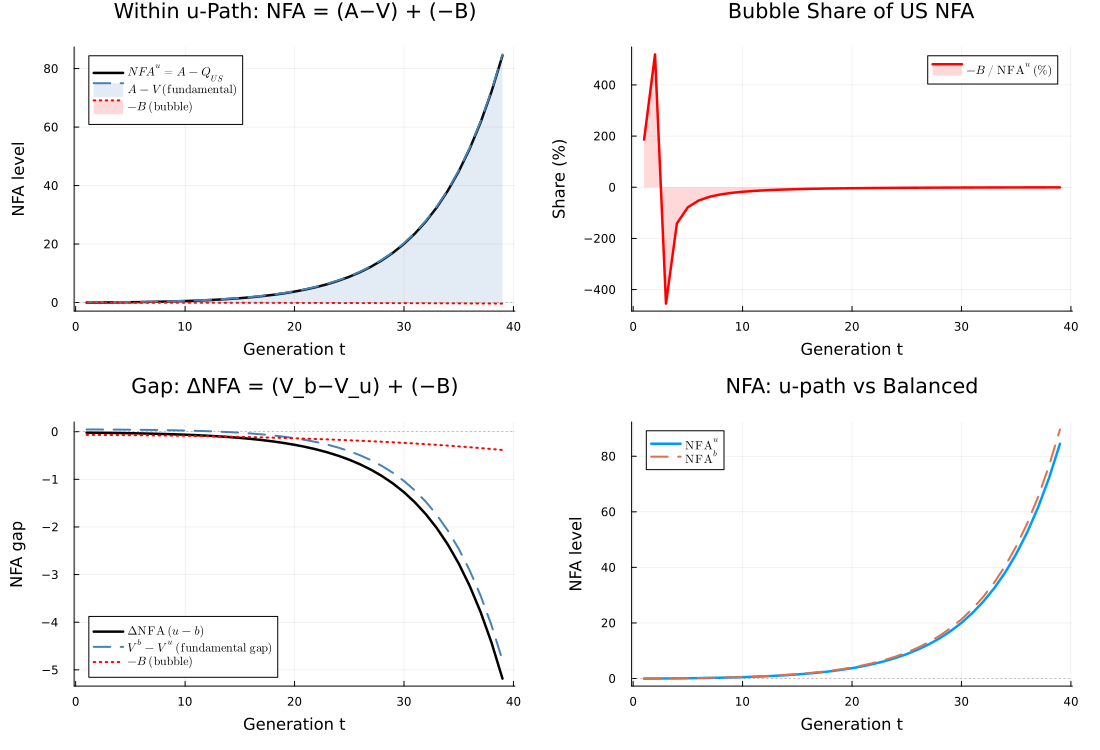

In [11]:
# ── Plot: NFA Decomposition ──
tt_pre = 1:tau-1

# Panel 1: Within-path decomposition  NFA = (A-V) + (-B)
p1 = plot(tt_pre, NFA_u_total, lw=2.5, lc=:black,
          label=L"NFA^u = A - Q_{US}",
          xlabel="Generation t", ylabel="NFA level",
          title="Within u-Path: NFA = (A−V) + (−B)")
plot!(p1, tt_pre, NFA_fund_u, lw=2, ls=:dash, lc=:steelblue,
      label=L"A - V\ (\mathrm{fundamental})",
      fill=0, fillalpha=0.15, fc=:steelblue)
plot!(p1, tt_pre, NFA_bubble_u, lw=2, ls=:dot, lc=:red,
      label=L"-B\ (\mathrm{bubble})",
      fill=0, fillalpha=0.15, fc=:red)
hline!(p1, [0], lc=:gray, ls=:dot, lw=0.5, label="")

# Panel 2: Bubble share of total NFA
p2 = plot(tt_pre, bubble_nfa_share, lw=2.5, lc=:red,
          label=L"-B\ /\ \mathrm{NFA}^u\ (\%)",
          xlabel="Generation t", ylabel="Share (%)",
          title="Bubble Share of US NFA",
          fill=0, fillalpha=0.15, fc=:red)

# Panel 3: Gap decomposition  ΔNFA = (V_b-V_u) + (-B)
p3 = plot(tt_pre, delta_NFA, lw=2.5, lc=:black,
          label=L"\Delta\mathrm{NFA}\ (u - b)",
          xlabel="Generation t", ylabel="NFA gap",
          title="Gap: ΔNFA = (V_b−V_u) + (−B)")
plot!(p3, tt_pre, delta_V_effect, lw=2, ls=:dash, lc=:steelblue,
      label=L"V^b - V^u\ (\mathrm{fundamental\ gap})")
plot!(p3, tt_pre, delta_B_effect, lw=2, ls=:dot, lc=:red,
      label=L"-B\ (\mathrm{bubble})")
hline!(p3, [0], lc=:gray, ls=:dot, lw=0.5, label="")

# Panel 4: NFA comparison (u-path vs balanced)
NFA_b_at_t = [p.β * paths.e_US[t] - bs[t].Q_US_hat * paths.e_US[t] for t in tt_pre]
p4 = plot(tt_pre, NFA_u_total, lw=2.5, label=L"\mathrm{NFA}^u",
          xlabel="Generation t", ylabel="NFA level",
          title="NFA: u-path vs Balanced")
plot!(p4, tt_pre, NFA_b_at_t, lw=2, ls=:dash, label=L"\mathrm{NFA}^b")
hline!(p4, [0], lc=:gray, ls=:dot, lw=0.5, label="")

plot(p1, p2, p3, p4, layout=(2,2), size=(1100, 750), margin=5Plots.mm)

## 5. Equilibrium Diagnostics

How do equilibrium variables along the u-path compare with the balanced-state counterfactual?

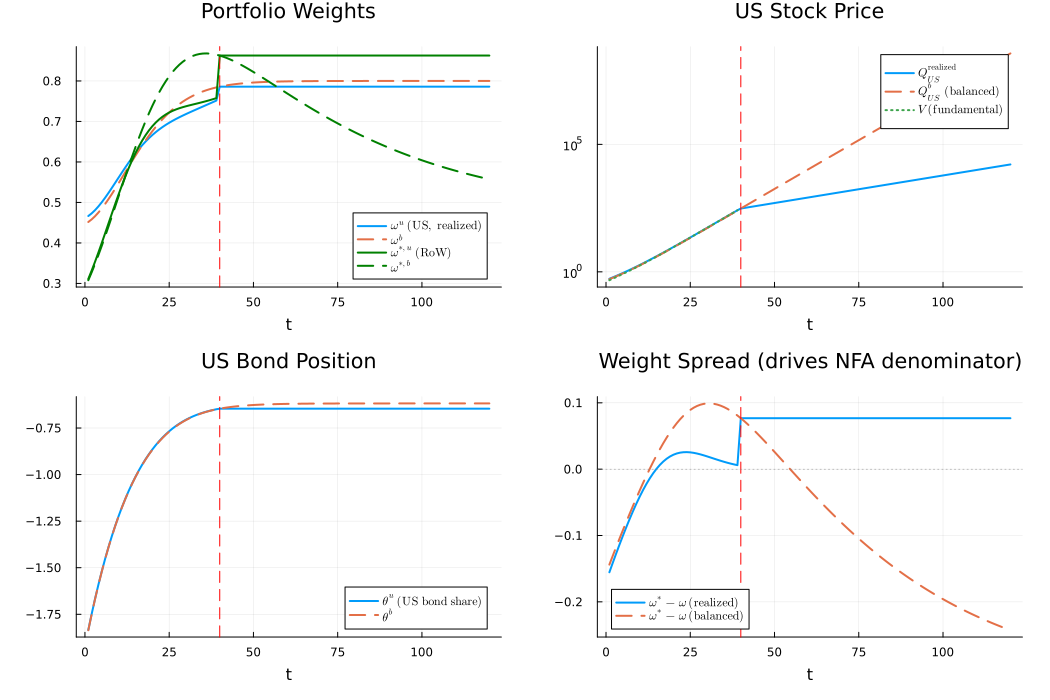

In [12]:
# ── Extract balanced-state series for comparison ──
omega_b_vec      = [bs[t].ω_b       for t in tt]
omega_star_b_vec = [bs[t].ω_star_b   for t in tt]
theta_b_vec      = [bs[t].θ_b        for t in tt]
Q_US_b_vec       = [bs[t].Q_US_hat * paths.e_US[t] for t in tt]

# Panel 1: Portfolio weights
ep1 = plot(tt, omega_real, lw=2, label=L"\omega^u\ (\mathrm{US,\ realized})",
           xlabel="t", title="Portfolio Weights")
plot!(ep1, tt, omega_b_vec, lw=2, ls=:dash, label=L"\omega^b")
plot!(ep1, tt, omega_star_real, lw=2, lc=:green, label=L"\omega^{*,u}\ (\mathrm{RoW})")
plot!(ep1, tt, omega_star_b_vec, lw=2, ls=:dash, lc=:green, label=L"\omega^{*,b}")
vline!(ep1, [tau], lc=:red, ls=:dash, lw=1, label="")

# Panel 2: Stock prices
ep2 = plot(tt, Q_US_real, lw=2, label=L"Q_{US}^{\mathrm{realized}}",
           xlabel="t", title="US Stock Price", yscale=:log10)
plot!(ep2, tt, Q_US_b_vec, lw=2, ls=:dash, label=L"Q_{US}^b\ (\mathrm{balanced})")
plot!(ep2, tt[1:tau-1], V[1:tau-1], lw=2, ls=:dot, label=L"V\ (\mathrm{fundamental})")
vline!(ep2, [tau], lc=:red, ls=:dash, lw=1, label="")

# Panel 3: Bond shares
ep3 = plot(tt, theta_real, lw=2, label=L"\theta^u\ (\mathrm{US\ bond\ share})",
           xlabel="t", title="US Bond Position")
plot!(ep3, tt, theta_b_vec, lw=2, ls=:dash, label=L"\theta^b")
vline!(ep3, [tau], lc=:red, ls=:dash, lw=1, label="")

# Panel 4: Weight spread (omega* - omega)
spread_u = omega_star_real .- omega_real
spread_b = omega_star_b_vec .- omega_b_vec
ep4 = plot(tt, spread_u, lw=2, label=L"\omega^* - \omega\ (\mathrm{realized})",
           xlabel="t", title="Weight Spread (drives NFA denominator)")
plot!(ep4, tt, spread_b, lw=2, ls=:dash, label=L"\omega^* - \omega\ (\mathrm{balanced})")
vline!(ep4, [tau], lc=:red, ls=:dash, lw=1, label="")
hline!(ep4, [0], lc=:gray, ls=:dot, lw=0.5, label="")

plot(ep1, ep2, ep3, ep4, layout=(2,2), size=(1050, 700), margin=5Plots.mm)

At t = 40 (switch date):
  Q_US:    u-path = 3.1072e+02 → balanced = 3.0465e+02  (Δ = -2.0%)
  NFA:     u-path = 9.8862e+01 → balanced = 1.0493e+02  (Δ = +6.0671e+00)
  NFA/GDP: u-path = 0.1207 → balanced = 0.1281
  ω:       u-path = 0.7552  → balanced = 0.7859


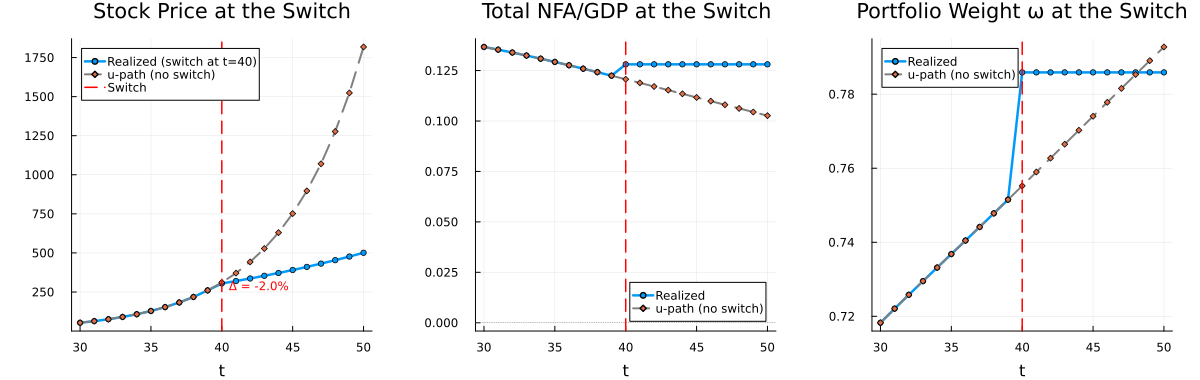

In [13]:
# ── Event Study: Crash at t = tau ──
# Compare u-path vs balanced-state at the SAME date t = tau

# What would Q_US be at tau if u continued?
Q_US_u_at_tau = u_path[tau].Q_US
Q_US_b_at_tau = bs[tau].Q_US_hat * paths.e_US[tau]
crash_pct = (Q_US_b_at_tau - Q_US_u_at_tau) / Q_US_u_at_tau * 100

# NFA comparison at tau (total NFA = A - Q_US)
A_at_tau = p.β * paths.e_US[tau]
NFA_u_at_tau = A_at_tau - Q_US_u_at_tau
NFA_b_at_tau = A_at_tau - Q_US_b_at_tau
nfa_change = NFA_b_at_tau - NFA_u_at_tau

# Portfolio weight comparison at tau
omega_u_at_tau = u_path[tau].ω
omega_b_at_tau = bs[tau].ω_b

@printf("At t = %d (switch date):\n", tau)
@printf("  Q_US:    u-path = %.4e → balanced = %.4e  (Δ = %+.1f%%)\n",
        Q_US_u_at_tau, Q_US_b_at_tau, crash_pct)
@printf("  NFA:     u-path = %.4e → balanced = %.4e  (Δ = %+.4e)\n",
        NFA_u_at_tau, NFA_b_at_tau, nfa_change)
@printf("  NFA/GDP: u-path = %.4f → balanced = %.4f\n",
        NFA_u_at_tau/paths.e_US[tau], NFA_b_at_tau/paths.e_US[tau])
@printf("  ω:       u-path = %.4f  → balanced = %.4f\n",
        omega_u_at_tau, omega_b_at_tau)

# ── Window around switch for plots ──
win = max(1, tau-10):min(T, tau+10)

# Panel 1: Stock price
Q_US_u_path_win = [u_path[t].Q_US for t in win]
ev1 = plot(win, Q_US_real[win], lw=2.5, marker=:circle, ms=3,
           label="Realized (switch at t=$tau)", xlabel="t",
           title="Stock Price at the Switch")
plot!(ev1, win, Q_US_u_path_win, lw=2, ls=:dash, marker=:diamond, ms=3,
      label="u-path (no switch)", lc=:gray)
vline!(ev1, [tau], lc=:red, ls=:dash, lw=1.5, label="Switch")
annotate!(ev1, tau+0.5, Q_US_b_at_tau*0.95,
          text(@sprintf("Δ = %.1f%%", crash_pct), 8, :left, crash_pct < 0 ? :red : :blue))

# Panel 2: Total NFA/GDP  (= β − Q_US_hat)
nfa_u_path_win = [p.β - u_path[t].Q_US / paths.e_US[t] for t in win]
ev2 = plot(win, nfa_gdp_real[win], lw=2.5, marker=:circle, ms=3,
           label="Realized", xlabel="t",
           title="Total NFA/GDP at the Switch")
plot!(ev2, win, nfa_u_path_win, lw=2, ls=:dash, marker=:diamond, ms=3,
      label="u-path (no switch)", lc=:gray)
vline!(ev2, [tau], lc=:red, ls=:dash, lw=1.5, label="")
hline!(ev2, [0], lc=:gray, ls=:dot, lw=0.5, label="")

# Panel 3: Portfolio weight
omega_u_path_win = [u_path[t].ω for t in win]
ev3 = plot(win, omega_real[win], lw=2.5, marker=:circle, ms=3,
           label="Realized", xlabel="t",
           title="Portfolio Weight ω at the Switch")
plot!(ev3, win, omega_u_path_win, lw=2, ls=:dash, marker=:diamond, ms=3,
      label="u-path (no switch)", lc=:gray)
vline!(ev3, [tau], lc=:red, ls=:dash, lw=1.5, label="")

plot(ev1, ev2, ev3, layout=(1,3), size=(1200, 380), margin=5Plots.mm)

## 6. Summary

### How US Stock Bubbles Drive Stock Prices
- Along the u-path, the US stock price $Q_{US}$ exceeds its fundamental value $V$ by a bubble component $B > 0$.
- The bubble share $B/Q$ is highest at early dates and declines over time.
- At $t = \tau = 40$, when the regime switches, the bubble bursts.

### The NFA Identity: $\text{NFA} = A - Q_{US}$

US Total NFA (equity + bonds) is:

$$\text{NFA}_{US} = \underbrace{(1-\omega)S}_{\text{US holdings of RoW equity}} - \underbrace{\omega^* S^*}_{\text{RoW holdings of US equity}} + \underbrace{b}_{\text{US bond position}} = A - Q_{US}$$

where $S = (1-\theta)A$, $S^* = (1-\theta^*_{US}-\theta^*_W)A^*$, and $b = \theta A$.

**Key insight**: Portfolio weights ($\omega$, $\omega^*$) cancel out through the stock clearing identity $Q_{US} = \omega S + \omega^* S^*$. NFA depends only on savings and stock prices.

### NFA Decomposition

Since $Q_{US} = V + B$:

$$\text{NFA} = \underbrace{(A - V)}_{\text{fundamental NFA}} + \underbrace{(-B)}_{\text{bubble effect}}$$

- The bubble $B > 0$ directly **reduces** NFA by inflating stock market capitalization above fundamentals.
- When the bubble bursts at $t = \tau$, $B \to 0$ and NFA jumps up toward the balanced-state level.

### Gap vs Balanced State

$$\Delta\text{NFA} = \text{NFA}^u - \text{NFA}^b = \underbrace{(V^b - V^u)}_{\text{fundamental value gap}} + \underbrace{(-B)}_{\text{bubble}}$$

Both components are exactly additive — derived from equilibrium identities, not approximations.